In [1]:
# cell 1

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cell 2

PROJECT_ROOT = os.path.abspath("..")
results_path = os.path.join(PROJECT_ROOT, "results", "raw_results.csv")

results_df = pd.read_csv(results_path)

print("Dataset Shape:", results_df.shape)
results_df.head()

Dataset Shape: (240, 6)


,Noise_Type,Noise_Rate,Fold,Model,Accuracy,F1
0,symmetric,0.0,1,Logistic Regression,0.973684,0.978723
1,symmetric,0.0,1,Decision Tree,0.929825,0.943662
2,symmetric,0.0,1,Random Forest,0.964912,0.971429
3,symmetric,0.0,1,SVM,0.991228,0.992908
4,symmetric,0.0,1,KNN,0.982456,0.986111


In [3]:
# cell 3

print("Models:", results_df["Model"].unique())
print("Noise types:", results_df["Noise_Type"].unique())
print("Noise levels:", results_df["Noise_Rate"].unique())

Models: <StringArray>
['Logistic Regression',       'Decision Tree',       'Random Forest',
                 'SVM',                 'KNN',            'LightGBM']
Length: 6, dtype: str
Noise types: <StringArray>
['symmetric', 'asymmetric']
Length: 2, dtype: str
Noise levels: [0.  0.1 0.2 0.3]


In [4]:
# cell 4

summary_df = (
    results_df
    .groupby(["Noise_Type","Noise_Rate","Model"])
    .agg(
        Mean_Accuracy=("Accuracy","mean"),
        Std_Accuracy=("Accuracy","std"),
        Mean_F1=("F1","mean"),
        Std_F1=("F1","std")
    )
    .reset_index()
)

summary_df.head(10)

,Noise_Type,Noise_Rate,Model,Mean_Accuracy,Std_Accuracy,Mean_F1,Std_F1
0,asymmetric,0.0,Decision Tree,0.913880,0.023555,0.932321,0.016593
1,asymmetric,0.0,KNN,0.963096,0.019997,0.971183,0.015380
2,asymmetric,0.0,LightGBM,0.966636,0.014371,0.973749,0.011023
3,asymmetric,0.0,Logistic Regression,0.973669,0.018590,0.979434,0.014227
4,asymmetric,0.0,Random Forest,0.956078,0.012351,0.965024,0.009865
5,asymmetric,0.0,SVM,0.977162,0.018179,0.981990,0.014344
6,asymmetric,0.1,Decision Tree,0.864710,0.021779,0.885475,0.019225
7,asymmetric,0.1,KNN,0.945552,0.016785,0.956311,0.013437
8,asymmetric,0.1,LightGBM,0.952585,0.021068,0.962018,0.016656
9,asymmetric,0.1,Logistic Regression,0.959618,0.020151,0.967450,0.016463


In [5]:
# cell 5

summary_df.to_csv("../results/summary_results.csv", index=False)

In [6]:
# cell 6

relative_results = []

for noise_type in summary_df["Noise_Type"].unique():

    type_df = summary_df[summary_df["Noise_Type"] == noise_type]

    for model in type_df["Model"].unique():

        model_df = type_df[type_df["Model"] == model]

        baseline_acc = model_df[model_df["Noise_Rate"] == 0.0]["Mean_Accuracy"].values[0]

        for _, row in model_df.iterrows():

            relative_drop = (baseline_acc - row["Mean_Accuracy"]) / baseline_acc

            relative_results.append({
                "Noise_Type": noise_type,
                "Noise_Rate": row["Noise_Rate"],
                "Model": model,
                "Relative_Drop": relative_drop
            })

relative_df = pd.DataFrame(relative_results)

relative_df.head()

,Noise_Type,Noise_Rate,Model,Relative_Drop
0,asymmetric,0.0,Decision Tree,0.000000
1,asymmetric,0.1,Decision Tree,0.053803
2,asymmetric,0.2,Decision Tree,0.101898
3,asymmetric,0.3,Decision Tree,0.182814
4,asymmetric,0.0,KNN,0.000000


In [7]:
# cell 7

relative_df.to_csv("../results/relative_drop.csv", index=False)

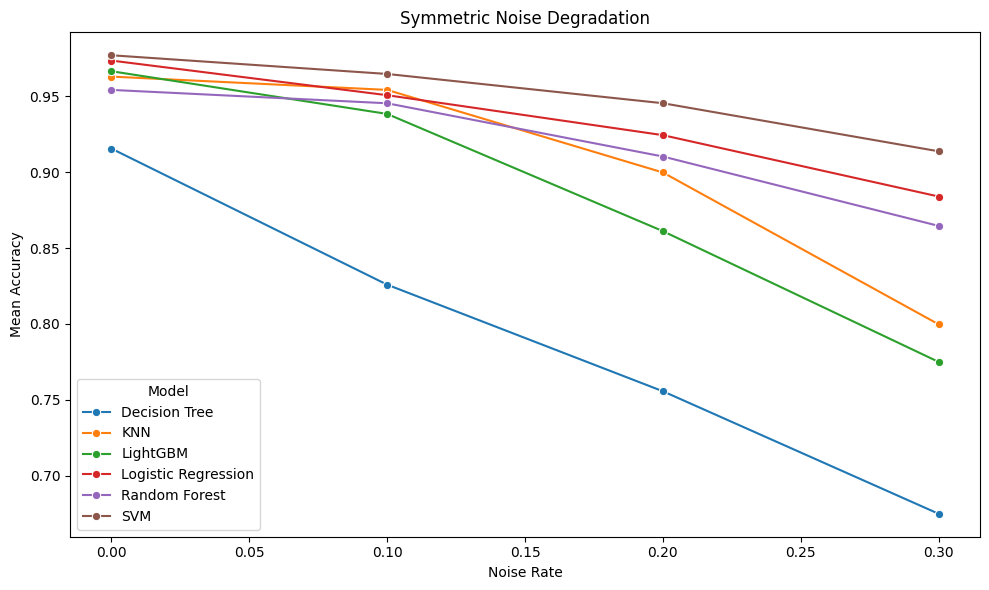

In [8]:
# cell 8

plt.figure(figsize=(10,6))

sns.lineplot(
    data=summary_df[summary_df["Noise_Type"]=="symmetric"],
    x="Noise_Rate",
    y="Mean_Accuracy",
    hue="Model",
    marker="o"
)

plt.title("Symmetric Noise Degradation")
plt.ylabel("Mean Accuracy")
plt.xlabel("Noise Rate")

plt.tight_layout()

plt.savefig("../figures/symmetric_degradation.png", dpi=300)

plt.show()

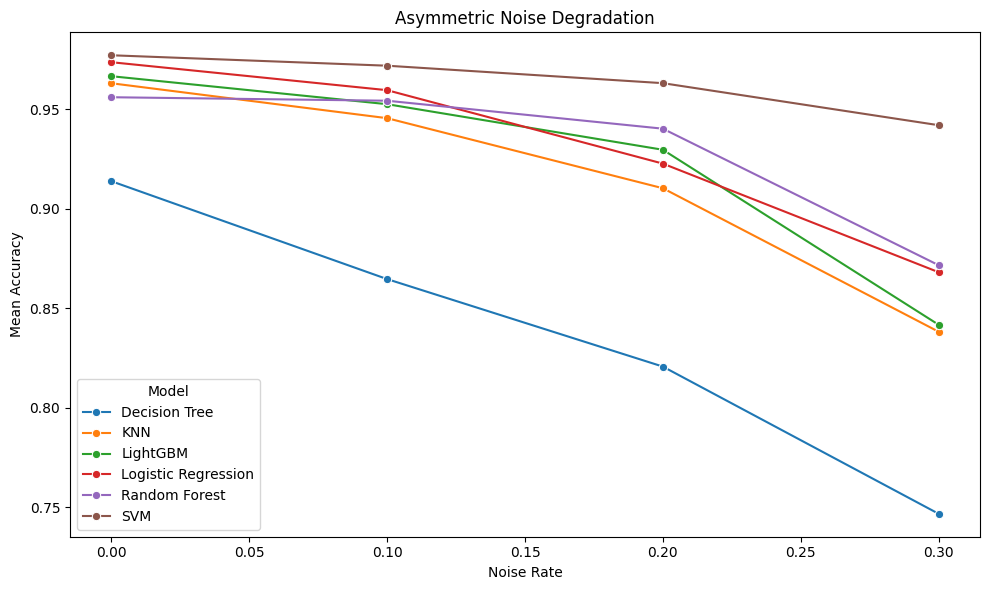

In [9]:
# cell 9

plt.figure(figsize=(10,6))

sns.lineplot(
    data=summary_df[summary_df["Noise_Type"]=="asymmetric"],
    x="Noise_Rate",
    y="Mean_Accuracy",
    hue="Model",
    marker="o"
)

plt.title("Asymmetric Noise Degradation")
plt.ylabel("Mean Accuracy")
plt.xlabel("Noise Rate")

plt.tight_layout()

plt.savefig("../figures/asymmetric_degradation.png", dpi=300)

plt.show()

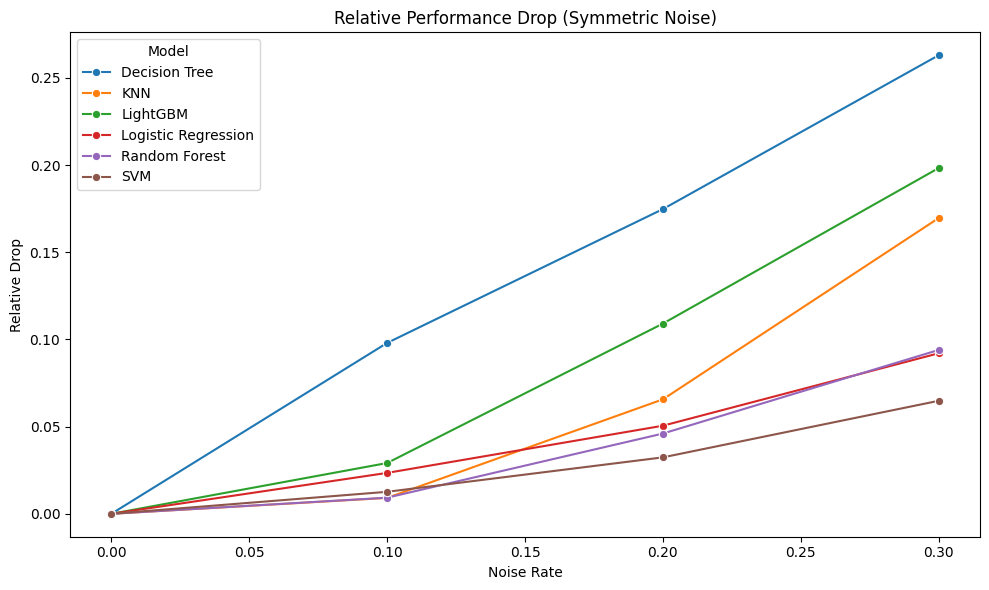

In [10]:
# cell 10

plt.figure(figsize=(10,6))

sns.lineplot(
    data=relative_df[relative_df["Noise_Type"]=="symmetric"],
    x="Noise_Rate",
    y="Relative_Drop",
    hue="Model",
    marker="o"
)

plt.title("Relative Performance Drop (Symmetric Noise)")
plt.ylabel("Relative Drop")
plt.xlabel("Noise Rate")

plt.tight_layout()

plt.savefig("../figures/relative_drop_symmetric.png", dpi=300)

plt.show()

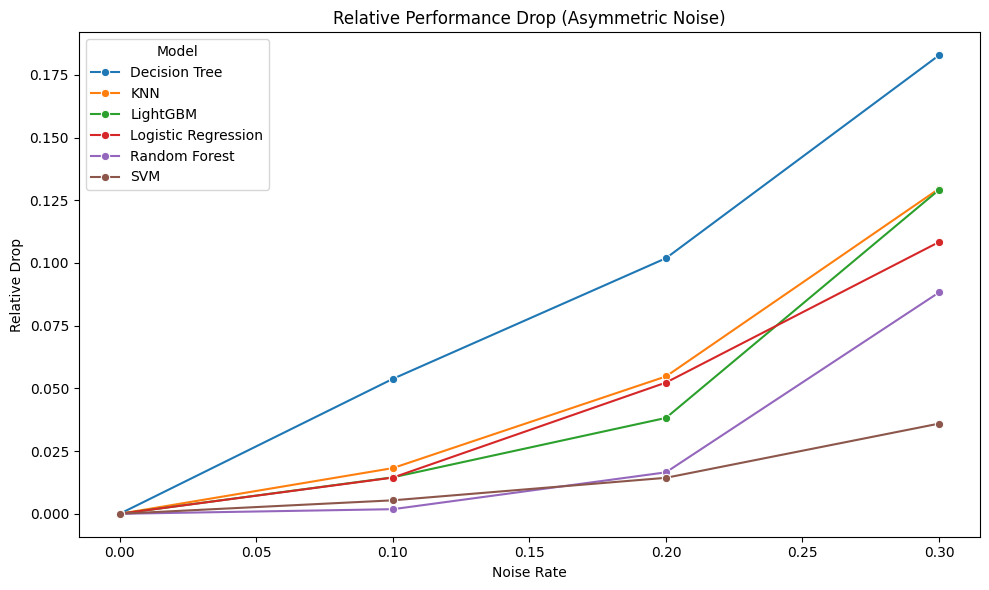

In [11]:
# cell 11

plt.figure(figsize=(10,6))

sns.lineplot(
    data=relative_df[relative_df["Noise_Type"]=="asymmetric"],
    x="Noise_Rate",
    y="Relative_Drop",
    hue="Model",
    marker="o"
)

plt.title("Relative Performance Drop (Asymmetric Noise)")
plt.ylabel("Relative Drop")
plt.xlabel("Noise Rate")

plt.tight_layout()

plt.savefig("../figures/relative_drop_asymmetric.png", dpi=300)

plt.show()

In [12]:
# cell 12

robustness_table = (
    relative_df
    .groupby(["Noise_Type","Model"])["Relative_Drop"]
    .max()
    .reset_index()
    .sort_values(["Noise_Type","Relative_Drop"])
)

robustness_table

,Noise_Type,Model,Relative_Drop
5,asymmetric,SVM,0.035955
4,asymmetric,Random Forest,0.088258
3,asymmetric,Logistic Regression,0.108349
2,asymmetric,LightGBM,0.129166
1,asymmetric,KNN,0.129608
0,asymmetric,Decision Tree,0.182814
11,symmetric,SVM,0.064809
9,symmetric,Logistic Regression,0.092069
10,symmetric,Random Forest,0.093968
7,symmetric,KNN,0.169619


In [13]:
# cell 13

robustness_table.to_csv("../results/robustness_ranking.csv", index=False)

In [14]:
# cell 14

comparison_df = summary_df.pivot_table(
    index=["Noise_Rate","Model"],
    columns="Noise_Type",
    values="Mean_Accuracy"
).reset_index()

comparison_df["Accuracy_Difference"] = (
    comparison_df["symmetric"] - comparison_df["asymmetric"]
)

comparison_df

Noise_Type,Noise_Rate,Model,asymmetric,symmetric,Accuracy_Difference
0,0.0,Decision Tree,0.913880,0.915634,0.001754
1,0.0,KNN,0.963096,0.963096,0.000000
2,0.0,LightGBM,0.966636,0.966636,0.000000
3,0.0,Logistic Regression,0.973669,0.973669,0.000000
4,0.0,Random Forest,0.956078,0.954324,-0.001754
5,0.0,SVM,0.977162,0.977162,0.000000
6,0.1,Decision Tree,0.864710,0.825897,-0.038814
7,0.1,KNN,0.945552,0.954324,0.008772
8,0.1,LightGBM,0.952585,0.938488,-0.014097
9,0.1,Logistic Regression,0.959618,0.950831,-0.008787


In [15]:
# cell 15

from scipy.stats import linregress

slope_results = []

for (noise_type, model), group in summary_df.groupby(["Noise_Type","Model"]):

    slope, intercept, r, p, stderr = linregress(
        group["Noise_Rate"],
        group["Mean_Accuracy"]
    )

    slope_results.append({
        "Noise_Type": noise_type,
        "Model": model,
        "Degradation_Slope": slope
    })

slope_df = pd.DataFrame(slope_results)

slope_df

,Noise_Type,Model,Degradation_Slope
0,asymmetric,Decision Tree,-0.545164
1,asymmetric,KNN,-0.409672
2,asymmetric,LightGBM,-0.397469
3,asymmetric,Logistic Regression,-0.353377
4,asymmetric,Random Forest,-0.267195
5,asymmetric,SVM,-0.114175
6,symmetric,Decision Tree,-0.792734
7,symmetric,KNN,-0.544527
8,symmetric,LightGBM,-0.652337
9,symmetric,Logistic Regression,-0.295280


In [16]:
# cell 16

model_category = {
    "Logistic Regression": "Linear",
    "SVM": "Margin-based",
    "KNN": "Instance-based",
    "Decision Tree": "Tree",
    "Random Forest": "Ensemble",
    "LightGBM": "Boosting"
}

summary_df["Model_Type"] = summary_df["Model"].map(model_category)

In [17]:
# cell 17

category_analysis = (
    summary_df
    .groupby(["Noise_Type","Noise_Rate","Model_Type"])
    ["Mean_Accuracy"]
    .mean()
    .reset_index()
)

category_analysis

,Noise_Type,Noise_Rate,Model_Type,Mean_Accuracy
0,asymmetric,0.0,Boosting,0.966636
1,asymmetric,0.0,Ensemble,0.956078
2,asymmetric,0.0,Instance-based,0.963096
3,asymmetric,0.0,Linear,0.973669
4,asymmetric,0.0,Margin-based,0.977162
5,asymmetric,0.0,Tree,0.913880
6,asymmetric,0.1,Boosting,0.952585
7,asymmetric,0.1,Ensemble,0.954324
8,asymmetric,0.1,Instance-based,0.945552
9,asymmetric,0.1,Linear,0.959618


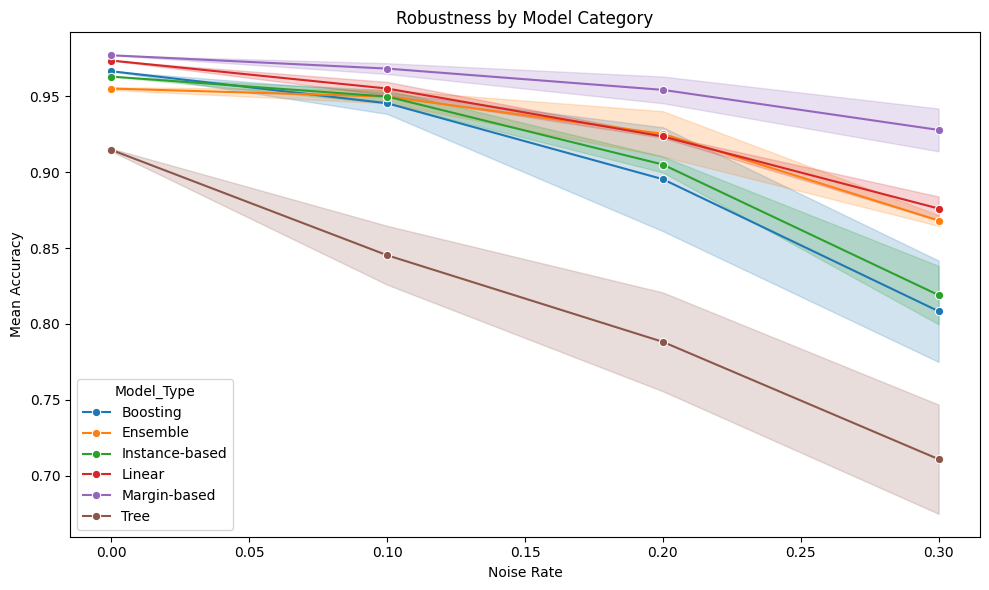

In [18]:
# cell 18

plt.figure(figsize=(10,6))

sns.lineplot(
    data=category_analysis,
    x="Noise_Rate",
    y="Mean_Accuracy",
    hue="Model_Type",
    marker="o"
)

plt.title("Robustness by Model Category")
plt.ylabel("Mean Accuracy")
plt.xlabel("Noise Rate")

plt.tight_layout()

plt.savefig("../figures/category_robustness.png", dpi=300)

plt.show()

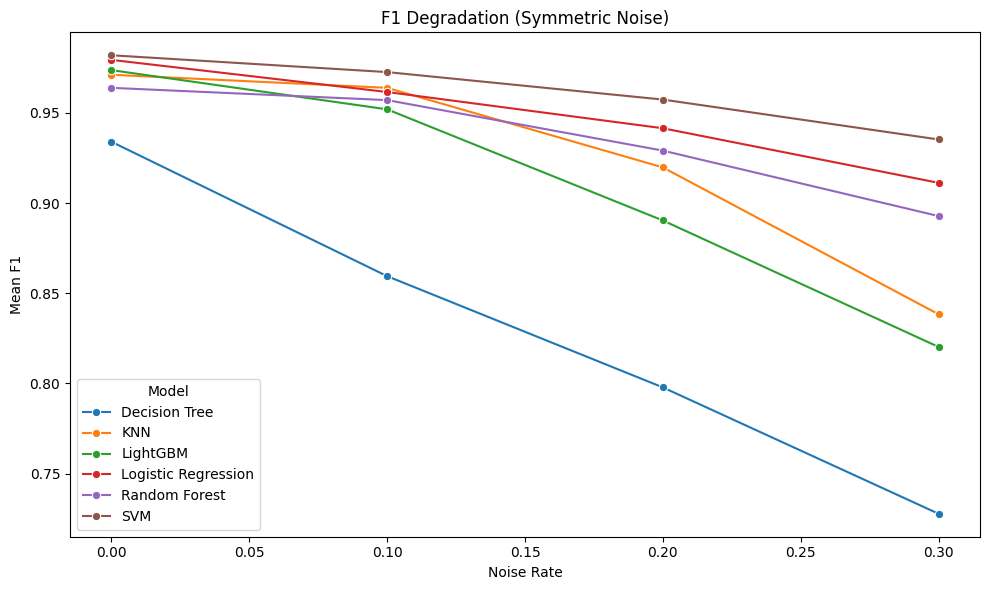

In [19]:
# cell 19

plt.figure(figsize=(10,6))

sns.lineplot(
    data=summary_df[summary_df["Noise_Type"]=="symmetric"],
    x="Noise_Rate",
    y="Mean_F1",
    hue="Model",
    marker="o"
)

plt.title("F1 Degradation (Symmetric Noise)")
plt.ylabel("Mean F1")
plt.xlabel("Noise Rate")

plt.tight_layout()

plt.savefig("../figures/f1_symmetric.png", dpi=300)

plt.show()

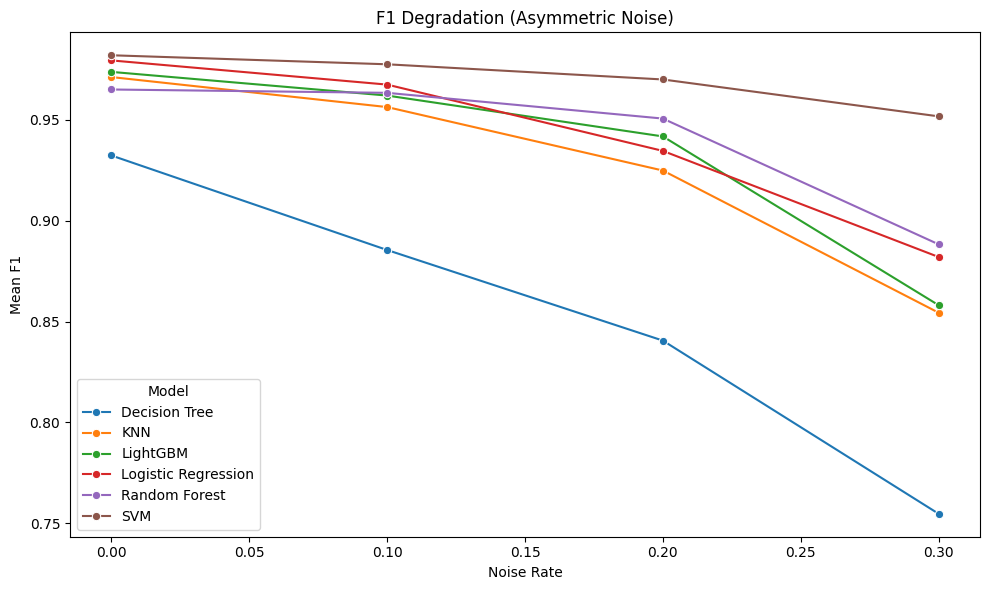

In [20]:
# cell 20

plt.figure(figsize=(10,6))

sns.lineplot(
    data=summary_df[summary_df["Noise_Type"]=="asymmetric"],
    x="Noise_Rate",
    y="Mean_F1",
    hue="Model",
    marker="o"
)

plt.title("F1 Degradation (Asymmetric Noise)")
plt.ylabel("Mean F1")
plt.xlabel("Noise Rate")

plt.tight_layout()

plt.savefig("../figures/f1_asymmetric.png", dpi=300)

plt.show()

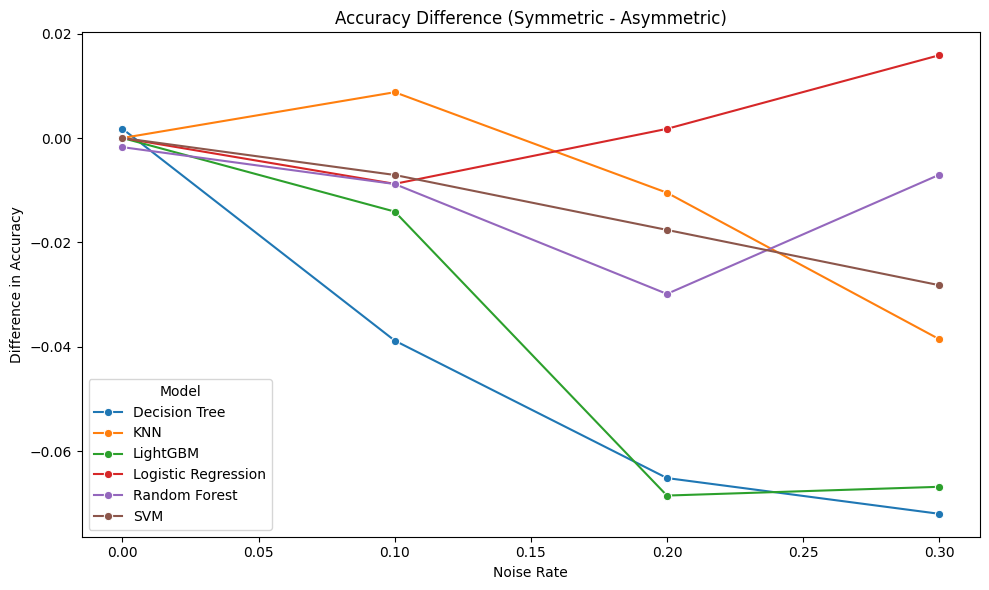

In [21]:
# SYMMETRIC VS ASYMMETRIC COMPARISON

comparison_df = summary_df.pivot_table(
    index=["Noise_Rate", "Model"],
    columns="Noise_Type",
    values="Mean_Accuracy"
).reset_index()

comparison_df["Difference"] = (
    comparison_df["symmetric"] - comparison_df["asymmetric"]
)

plt.figure(figsize=(10,6))
sns.lineplot(
    data=comparison_df,
    x="Noise_Rate",
    y="Difference",
    hue="Model",
    marker="o"
)
plt.title("Accuracy Difference (Symmetric - Asymmetric)")
plt.ylabel("Difference in Accuracy")
plt.xlabel("Noise Rate")
plt.tight_layout()
plt.savefig("../figures/symmetric_vs_asymmetric.png", dpi=300)
plt.show()

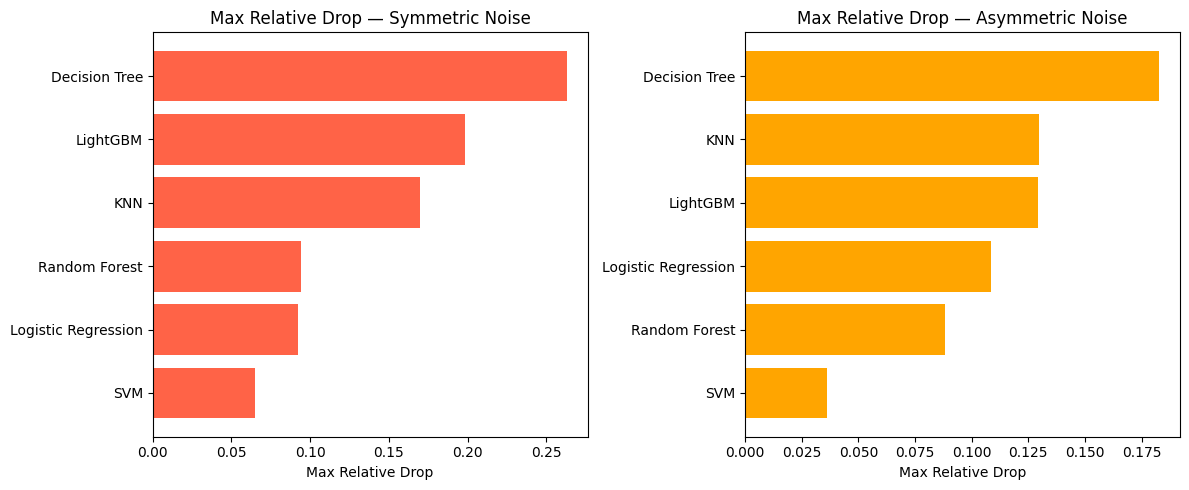

In [22]:
def plot_robustness_ranking(relative_df):
    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    for i, noise_type in enumerate(["symmetric", "asymmetric"]):
        temp = (
            relative_df[relative_df["Noise_Type"] == noise_type]
            .groupby("Model")["Relative_Drop"]
            .max()
            .sort_values(ascending=False)
        )

        axes[i].barh(temp.index, temp.values, color="tomato" if noise_type=="symmetric" else "orange")
        axes[i].set_title(f"Max Relative Drop — {noise_type.capitalize()} Noise")
        axes[i].set_xlabel("Max Relative Drop")
        axes[i].invert_yaxis()

    plt.tight_layout()
    plt.savefig("../figures/robustness_ranking.png", dpi=300)
    plt.show()

# call
plot_robustness_ranking(relative_df)

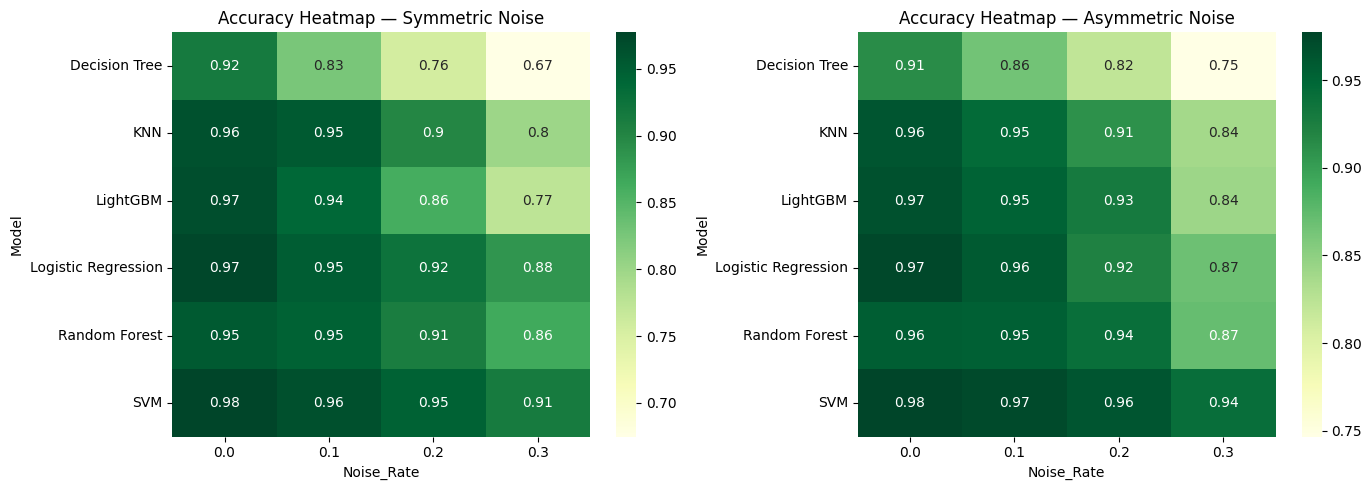

In [23]:
def plot_accuracy_heatmap(summary_df):
    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    for i, noise_type in enumerate(["symmetric", "asymmetric"]):
        pivot = summary_df[summary_df["Noise_Type"] == noise_type] \
            .pivot(index="Model", columns="Noise_Rate", values="Mean_Accuracy")

        sns.heatmap(pivot, annot=True, cmap="YlGn", ax=axes[i])
        axes[i].set_title(f"Accuracy Heatmap — {noise_type.capitalize()} Noise")

    plt.tight_layout()
    plt.savefig("../figures/accuracy_heatmap.png", dpi=300)
    plt.show()

# call
plot_accuracy_heatmap(summary_df)

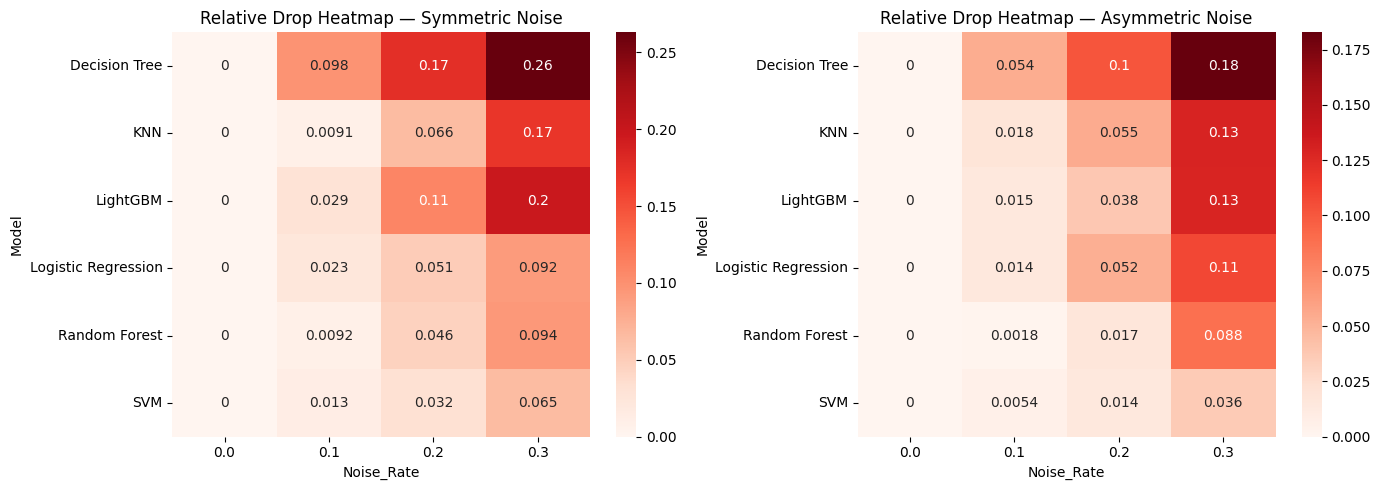

In [24]:
def plot_relative_drop_heatmap(relative_df):
    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    for i, noise_type in enumerate(["symmetric", "asymmetric"]):
        pivot = relative_df[relative_df["Noise_Type"] == noise_type] \
            .pivot(index="Model", columns="Noise_Rate", values="Relative_Drop")

        sns.heatmap(pivot, annot=True, cmap="Reds", ax=axes[i])
        axes[i].set_title(f"Relative Drop Heatmap — {noise_type.capitalize()} Noise")

    plt.tight_layout()
    plt.savefig("../figures/relative_drop_heatmap.png", dpi=300)
    plt.show()

# call
plot_relative_drop_heatmap(relative_df)

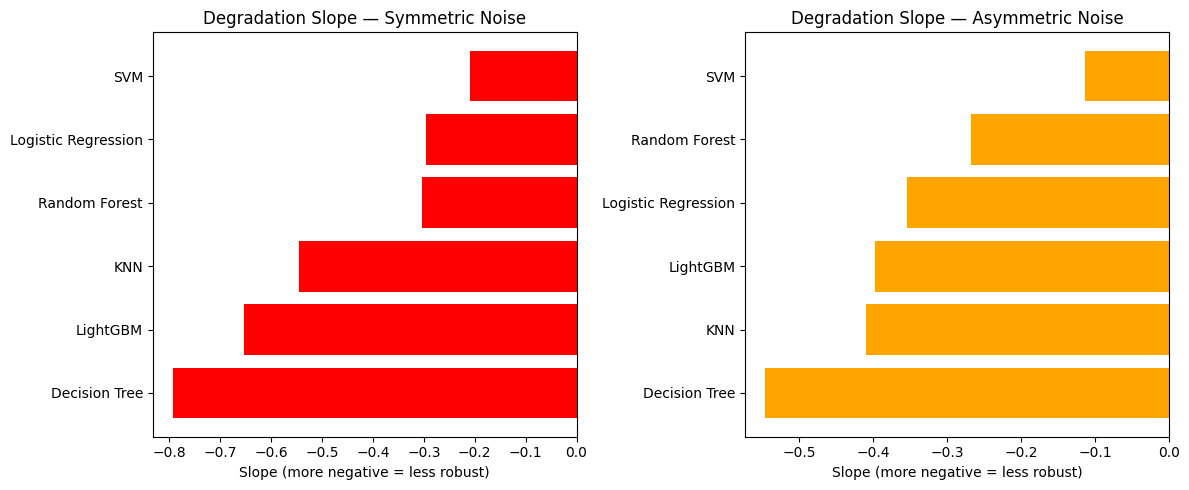

In [25]:
def plot_degradation_slope(slope_df):
    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    for i, noise_type in enumerate(["symmetric", "asymmetric"]):
        temp = slope_df[slope_df["Noise_Type"] == noise_type] \
            .sort_values("Degradation_Slope")

        axes[i].barh(temp["Model"], temp["Degradation_Slope"], color="red" if noise_type=="symmetric" else "orange")
        axes[i].set_title(f"Degradation Slope — {noise_type.capitalize()} Noise")
        axes[i].set_xlabel("Slope (more negative = less robust)")

    plt.tight_layout()
    plt.savefig("../figures/degradation_slope.png", dpi=300)
    plt.show()

# call
plot_degradation_slope(slope_df)